## **Import Library**

In [1]:
!pip install sastrawi
!pip install nltk
!pip install gensim
!pip install tensorflow
!pip install keras
!pip install vaderSentiment
!pip install num2words
!pip install pipreqs

In [2]:
 #menggunakan mpstemmer untuk mempercepat hasil stemming
!pip install python-Levenshtein
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.9 MB/s eta 0:00:00
  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-zfyz40en
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-zfyz40en
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
  Created wheel for mpstemmer: filename=mpstemmer-0.1.0-py3-none-any.whl size=99799 sha256=0c6ea26293468c86c3166a4a9f7545883c3ba34500dc8dfb1485e58b5c8d7869
  Stored in directory: /tmp/pip-ephem-wheel-cache-1l5fa50j/wheels/93/80/60/a333787af9e8f1757522a69783388d1d39e5adc2375b17d470
Successfully built mpstemmer


In [3]:
import pandas as pd # Pustaka untuk membuat dataframe
import numpy as np # pustaka untuk pengolahan angka
import matplotlib.pyplot as plt # Pustaka untuk visualisasi
import seaborn as sns # Pustaka untuk visualisasi

import re # Pustaka regex
import string #Pustaka untuk manipulasi string
import nltk  # Import pustaka NLTK (Natural Language Toolkit).
from nltk.tokenize import word_tokenize # Tokenisasi teks
from nltk.corpus import stopwords # Daftar kata-kata berhenti dalam teks
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia
from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer # Labelling menggunakan VADER
from num2words import num2words # Pustaka untuk merubah angka menjadi kata

In [4]:
# Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata yang tidak memiliki makna (stopwords)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## **Data Loading**

In [5]:
# Memuat dataset
df = pd.read_csv('/content/mobile_legends_review.csv')

In [6]:
# Menampilkan lima data teratas.
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9e5aa207-f0bb-4842-b123-1094652ede46,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,pengen dapat jarahan raja doang skip aja,5,0,1.9.93.10904,2025-07-07 07:21:36,NaN,NaN,1.9.93.10904
1,2c66286a-065b-4238-aea2-1977e5d221b0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,woi monton ini DM gue Napa tiba' kurang padaha...,1,0,1.9.93.10904,2025-07-07 07:21:34,NaN,NaN,1.9.93.10904
2,e2c3161b-2a1a-4628-aa0a-2228aaaf7dfb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,moonton sangat baik😍,5,0,1.9.93.10904,2025-07-07 07:21:24,NaN,NaN,1.9.93.10904
3,c2579200-537d-4515-be08-d163bf815c1a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"game yang bagus, saya suka dengan game mobile ...",5,0,1.9.93.10904,2025-07-07 07:21:09,NaN,NaN,1.9.93.10904
4,84faa2b9-6f99-40ad-9b7d-6885b85fe22e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,game ini main nya 5vs5 atu 1vs9 tolong perbaik...,1,1,1.9.70.10634,2025-07-07 07:20:57,NaN,NaN,1.9.70.10634


In [7]:
# Menampilkan lima data terakhir
df.tail()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
24995,2704f0b8-98fa-4307-abc2-183b74c6afa4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,permainan menyenangkan,4,0,1.9.93.10904,2025-07-03 17:53:43,NaN,NaN,1.9.93.10904
24996,7cef4674-f2e5-49e4-9f29-2e3fb72c1117,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,game bagus cuman sedikit saran kalo kasih tim ...,5,0,NaN,2025-07-03 17:53:41,NaN,NaN,NaN
24997,bbb27136-b3a0-4115-9cb5-e332175acecf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,yowes,5,0,NaN,2025-07-03 17:53:40,NaN,NaN,NaN
24998,e1b5b88b-404b-48be-9ac3-7f0f7b4b9d05,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ml game terbaik,5,0,1.9.93.10904,2025-07-03 17:53:15,NaN,NaN,1.9.93.10904
24999,61bd7af1-4f4e-4d66-8516-50973e0c81cf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,seru cuy,5,0,NaN,2025-07-03 17:53:03,NaN,NaN,NaN


In [8]:
# Menampilkan informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              25000 non-null  object
 1   userName              25000 non-null  object
 2   userImage             25000 non-null  object
 3   content               25000 non-null  object
 4   score                 25000 non-null  int64 
 5   thumbsUpCount         25000 non-null  int64 
 6   reviewCreatedVersion  19445 non-null  object
 7   at                    25000 non-null  object
 8   replyContent          361 non-null    object
 9   repliedAt             361 non-null    object
 10  appVersion            19445 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.1+ MB


Dataset ini berisi 25.000 ulasan pengguna terhadap Aplikasi 'Mobile Legends Bang Bang' di platform Playstore. Tujuan utama dari dataset ini adalah untuk menganalisis sentimen pengguna terhadap aplikasi berdasarkan ulasan teks (content) dan skor rating (score) yang diberikan.

## **Data Cleaning**

In [9]:
# membuang kolom yang tidak memiliki fungsi untuk model
columns= ['reviewId', 'userName', 'userImage', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt','appVersion']
df.drop(columns, axis=1, inplace=True)



Seperti yang sudah saya jelaskan saya hanya menggunakan kolom ulasan teks dan skor rating (score) untuk analisa sentimen saya. maka kolom lainnya akan saya hapus

In [10]:
# Cek jumlah missing values
print(df.isna().sum(),'\n')
# Cek duplicate values
print('Jumlah duplikasi data : ',df.duplicated().sum())

content    0
score      0
dtype: int64 

Jumlah duplikasi data :  6513


Tidak ada missing values (nilai kosong) tetapi terdapat Duplikasi data sebanyak 6513 pada dataset. Sehingga duplikasi data tersebut harus dihilangkan agar didapatkan data-data yang berbeda pada dataset tersebut.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  25000 non-null  object
 1   score    25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [12]:
# Menghapus duplikasi dan menyimpan hasilnya kembali ke df
df_cleaned = df.drop_duplicates()

In [13]:
# Cek banyak baris yang tersisa
print(f"Jumlah baris setelah menghapus duplikasi: {len(df_cleaned)}")

Jumlah baris setelah menghapus duplikasi: 18487


Jumlah baris yang tersisa setelah dilakukan adanya penghapusan duplikasi data sebanyak 18487. Ini masih melebihi dari ketentuan data minimal yaitu 10000. Sehingga 18487 data ini dapat digunakan pada proses selanjutnya yaitu text preprocessing.

## **Text Preprocessing**

### **Casefolding dan Text Cleaning**

In [14]:

# Case folding
def casefolding(text):
    text = text.lower()
    return text

# Text Cleaning
def cleaning(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # hapus mention
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)  # hapus hashtag
    text = re.sub(r'http\S+', '', text)         # hapus URL

    # Ubah angka ke teks
    def convert_number_to_words(match):
        number = int(match.group())
        return num2words(number, lang='id')  # Bahasa Indonesia

    text = re.sub(r'\d+', convert_number_to_words, text)
    text = text.replace('\n', ' ')  # hapus baris baru
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = text.strip() # menghapus karakter spasi
    return text

### **Tokenisasi dan filter stopword**

In [15]:
# Tokenisasi
def tokenizing(text):
    text = word_tokenize(text)
    return text

# Menghapus stopwords
def filtering(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','sih','sii','ku',"di","ga","ya","gaa","loh","kah","dong","woi","woii","woy","kan","deh","yang","yg","emang","memang"])
    filtered = []
    for txt in text:
        if txt.lower() not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

### **Normalisasi kata**

In [16]:
# Membuat dictionary kalimat slang yang dipakai oleh player

slang_dict = {
    "gg": "good game",
    "wp": "well played",
    "mvp": "most valuable player",
    "afk": "away from keyboard",
    "feeder": "pemain yang sering mati",
    "noob": "pemula",
    "pro": "profesional",
    "imba": "imbalance",
    "op": "overpowered",
    "nerf": "penyesuaian kekuatan agar tidak terlalu kuat",
    "buff": "penyesuaian kekuatan agar lebih kuat",
    "savage": "membunuh 5 hero lawan sekaligus",
    "maniac": "membunuh 4 hero lawan sekaligus",
    "legendary": "membunuh banyak hero lawan tanpa mati",
    "comeback": "membalikkan keadaan dari ketertinggalan",
    "push": "menyerang tower/turret",
    "farming": "mengumpulkan gold dan exp",
    "meta": "strategi atau hero yang sedang kuat",
    "roam": "bergerak antar lane untuk membantu rekan tim",
    "gank": "menyerang lawan secara tiba-tiba dengan lebih dari satu hero",
    "turtle": "monster netral yang memberikan gold dan exp",
    "lord": "monster netral terkuat yang membantu push lane",
    "mid": "jalur tengah",
    "exp lane": "jalur experience",
    "gold lane": "jalur gold",
    "jungler": "pemain yang fokus farming di jungle",
    "core": "hero utama yang menjadi damage dealer",
    "support": "hero yang membantu dan melindungi rekan tim",
    "tank": "hero yang menahan damage dan melindungi rekan tim",
    "mm": "marksman",
    "mage": "hero dengan magic damage",
    "assassin": "hero pembunuh",
    "fighter": "hero petarung",
    "ulti": "ultimate skill",
    "skill": "kemampuan hero",
    "cd": "cooldown",
    "mana": "energi untuk menggunakan skill",
    "regen": "regenerasi",
    "build": "susunan item hero",
    "item": "peralatan hero",
    "lag": "jaringan lambat",
    "ping": "kualitas koneksi internet",
    "dc": "disconnect",
    "report": "melaporkan pemain yang melanggar aturan",
    "toxic": "perilaku negatif",
    "micin": "istilah untuk pemain yang performanya buruk",
    "bucin": "budak cinta (sering digunakan untuk hero support yang selalu bersama core)",
    "santuy": "santai",
    "gabut": "tidak ada kerjaan/bosan",
    "mabar": "main bareng",
    "mabar kuy": "ayo main bareng",
    "kuy": "ayo",
    "gas": "ayo/mulai",
    "pick": "memilih hero",
    "ban": "melarang hero agar tidak bisa dipilih",
    "draft pick": "mode pemilihan hero dalam pertandingan ranked",
    "ranked": "mode peringkat",
    "classic": "mode biasa",
    "bocil": "bocah kecil",
    "rusuh": "membuat keributan/gangguan",
    "troll": "pemain yang sengaja merugikan tim",
    "ggwp": "good game well played",
    "ez": "easy",
    "gajelas": "tidak jelas",
    "njir": "anjir (kata seru)",
    "anjg": "anjing (kata umpatan)",
    "cnt": "contoh (singkatan)",
    "bkn": "bukan",
    "trs": "terus",
    "gpp": "tidak apa-apa",
    "byk": "banyak",
    "udh": "sudah",
    "yg": "yang",
    "kek": "seperti",
    "kyk": "seperti",
    "ngeselin": "mengesalkan",
    "parah": "sangat",
    "bet": "banget",
    "bgt": "banget",
    "kzl": "kesal",
    "sakit": "damage besar",
    "tipis": "darah sedikit",
    "tebal": "darah banyak/defensif",
    "ulti gagal": "ultimate skill gagal",
    "miss": "melenceng/gagal",
    "jleb": "suara efek serangan yang sakit",
    "ngendok": "bersembunyi",
    "bacot": "banyak bicara/toxic",
    "auto": "otomatis",
    "free": "gratis/mudah",
    "bikin": "membuat",
    "cpt": "cepat",
    "dlm": "dalam",
    "dr": "dari",
    "dpt": "dapat",
    "gtu": "begitu",
    "klo": "kalau",
    "knp": "kenapa",
    "krn": "karena",
    "lg": "lagi",
    "lgsg": "langsung",
    "pdhl": "padahal",
    "sm": "sama",
    "tp": "tapi",
    "tdk": "tidak",
    "udh": "sudah",
    "utk": "untuk",
    "brp": "berapa",
    "kpn": "kapan",
    "dmn": "dimana",
    "gmn": "bagaimana",
    "sy": "saya",
    "km": "kamu",
    "jg": "juga",
    "skrg": "sekarang",
    "nanti": "nanti",
    "lgsg": "langsung",
    "mungkin": "mungkin",
    "bnyk": "banyak",
    "dikit": "sedikit",
    "pake": "pakai",
    "doang": "saja",
    "banget": "sangat",
    "bangke": "bangsat (umpatan)",
    "cacad": "cacat (negatif)",
    "anjay": "anjir (kata seru)",
    "anying": "anjing (umpatan)",
    "goblog": "bodoh",
    "goblok": "bodoh",
    "tolol": "bodoh",
    "alay": "norak",
    "baper": "bawa perasaan",
    "galau": "bingung/sedih",
    "mager": "malas gerak",
    "sewot": "kesal",
    "curhat": "curahan hati",
    "modar": "mati",
    "cuy": "teman/bro",
    "gan": "juragan/tuan",
    "sis": "sister/kakak perempuan",
    "wkwk": "tertawa",
    "haha": "tertawa",
    "hehe": "tertawa",
    "lol": "laughing out loud",
    "njirr": "anjir (kata seru)",
    "cuk": "cuk (kata umpatan Jawa)",
    "tai": "kotoran (umpatan)",
    "asu": "anjing (umpatan Jawa)",
    "jangkrik": "jangkrik (seruan netral)",
    "buset": "buset (kata seru)",
    "anjrit": "anjir (kata seru)",
    "dih": "dih (seruan ekspresi kesal)",
    "etdah": "astaga",
    "kampret": "kampret (umpatan ringan)",
    "sialan": "sialan (umpatan ringan)",
    "brengsek": "brengsek (umpatan)",
    "najis": "najis (ekspresi jijik)",
    "ampun": "ampun",
    "maap": "maaf",
    "maapin": "maafkan",
    "napa": "kenapa",
    "gmn": "bagaimana",
    "tdr": "tidur",
    "mlm": "malam",
    "pgn": "pengen",
    "bgst": "bangsat (umpatan)",
    "bt": "bete/bosan",
    "ntar": "nanti",
    "ytta": "yang tahu tahu saja",
    "sbr": "sabar",
    "ngakak": "tertawa terbahak-bahak",
    "receh": "murahan/tidak penting",
    "bacot": "banyak omong",
    "mampus": "mati",
    "ngaco": "tidak benar",
    "bego": "bodoh",
    "cupu": "pemain lemah/penakut",
    "santuy": "santai",
    "gila": "tidak waras/luar biasa",
    "anjay mabar": "ayo main bareng (ekspresi seru)",
    "push rank": "meningkatkan peringkat",
    "akun": "akun",
    "bug": "kesalahan program",
    "patch": "pembaruan game",
    "event": "acara dalam game",
    "skin": "kostum hero",
    "hero": "karakter dalam game",
    "turret": "menara",
    "minion": "prajurit",
    "creep": "monster hutan",
    "jungle": "hutan",
    "lane": "jalur",
    "top": "atas",
    "bot": "bawah",
    "mid": "tengah",
    "base": "markas",
    "destroy": "hancurkan",
    "kill": "bunuh",
    "death": "mati",
    "assist": "bantuan",
    "team": "tim",
    "musuh": "lawan",
    "friend": "teman",
    "invite": "undang",
    "party": "kelompok",
    "lobby": "ruang tunggu",
    "matchmaking": "pencarian pertandingan",
    "report": "laporan",
    "suspend": "penangguhan",
    "ban": "larangan",
    "disconnect": "terputus",
    "reconnect": "terhubung kembali",
    "server": "server",
    "lag": "terlambat",
    "ping": "koneksi",
    "update": "pembaruan",
    "download": "unduh",
    "instal": "pasang",
    "hapus": "hapus",
    "cache": "cache",
    "data": "data",
    "setting": "pengaturan",
    "grafik": "grafis",
    "fps": "frames per second",
    "device": "perangkat",
    "hp": "handphone",
    "batre": "baterai",
    "panas": "panas",
    "lemot": "lambat",
    "ngecas": "mengisi daya",
    "kuota": "paket data",
    "wifi": "wifi",
    "provider": "penyedia layanan",
    "sinyal": "sinyal",
    "paket": "paket",
    "isi": "isi",
    "top up": "isi ulang",
    "diamond": "mata uang premium",
    "coin": "mata uang",
    "event": "acara",
    "gratis": "gratis",
    "hadiah": "hadiah",
    "voucher": "voucher",
    "kode": "kode",
    "klaim": "klaim",
    "redeem": "redeem",
    "bug": "bug",
    "error": "kesalahan",
    "force close": "tutup paksa",
    "crash": "rusak",
    "freeze": "macet",
    "hang": "macet",
    "lancar": "lancar",
    "rusak": "rusak",
    "perbaiki": "perbaiki",
    "reset": "reset",
    "hapus": "hapus",
    "instal ulang": "instal ulang",
    "review": "ulasan",
    "rating": "penilaian",
    "bintang": "bintang",
    "komplain": "keluhan",
    "saran": "saran",
    "kritik": "kritik",
    "pengembang": "pengembang",
    "developer": "pengembang",
    "admin": "administrator",
    "cs": "customer service",
    "support": "dukungan",
    "bantuan": "bantuan",
    "faq": "pertanyaan umum",
    "masalah": "masalah",
    "solusi": "solusi",
    "feedback": "umpan balik",
    "update": "pembaruan",
    "fitur": "fitur",
    "baru": "baru",
    "lama": "lama",
    "bagus": "bagus",
    "jelek": "jelek",
    "suka": "suka",
    "tidak suka": "tidak suka",
    "cinta": "cinta",
    "benci": "benci",
    "puas": "puas",
    "kecewa": "kecewa",
    "recommend": "merekomendasikan",
    "worth it": "sepadan",
    "rugi": "rugi",
    "untung": "untung",
    "menyesal": "menyesal",
    "senang": "senang",
    "sedih": "sedih",
    "marah": "marah",
    "kesal": "kesal",
    "lucu": "lucu",
    "seru": "seru",
    "bosan": "bosan",
    "capek": "capek",
    "semangat": "semangat",
    "menang": "menang",
    "kalah": "kalah",
    "imbang": "seri",
    "game": "permainan",
    "permainan": "permainan",
    "aplikasi": "aplikasi",
    "hp": "ponsel",
    "lag": "penundaan",
    "bug": "gangguan",
    "ngeframe": "gambar tersendat",
    "force close": "aplikasi tertutup paksa",
    "update": "pembaruan",
    "bugnya": "gangguan",
    "tolong": "mohon",
    "perbaiki": "memperbaiki",
    "terima kasih": "terima kasih",
    "mantap": "bagus sekali",
    "keren": "hebat",
    "parah": "sangat",
    "banget": "sekali",
    "bgt": "sekali",
    "bikin": "membuat",
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "gak": "tidak",
    "dpt": "dapat",
    "udh": "sudah",
    "sdh": "sudah",
    "dr": "dari",
    "aja": "saja",
    "tp": "tapi",
    "jd": "jadi",
    "blm": "belum",
    "yg": "yang",
    "sm": "sama",
    "trs": "terus",
    "krn": "karena",
    "kyk": "seperti",
    "knp": "kenapa",
    "ktnya": "katanya",
    "lg": "lagi",
    "lgsng": "langsung",
    "mending": "lebih baik",
    "org": "orang",
    "pdhl": "padahal",
    "sampe": "sampai",
    "udh": "sudah",
    "ujung2nya": "akhirnya",
    "zonk": "buruk",
    "bobrok": "rusak",
    "apk": "aplikasi",
    "jancok": "jelek",
    "jancoek": "jelek",
    "aplikasinya": "aplikasi",
    "aplikator": "aplikasi",
    "bnyk": "banyak",
    "bbrp": "beberapa",
    "ngefreeze": "macet",
    "pake": "pakai",
    "jaringan": "koneksi internet",
    "kuota": "paket data internet",
    "server": "pusat data",
    "lag": "keterlambatan",
    "bug": "cacat",
    "eror": "kesalahan",
    "ngebug": "mengalami gangguan",
    "bucin": "budak cinta",
    "rusuh": "membuat keributan",
    "trol": "pemain yang mengganggu",
    "gampang": "mudah",
    "susah": "sulit",
    "ribet": "rumit",
    "sering": "sering",
    "jarang": "jarang",
    "kadangan": "terkadang",
    "selalu": "selalu",
    "tidak pernah": "tidak pernah",
    "pernah": "pernah",
    "harus": "harus",
    "wajib": "wajib",
    "bisa": "bisa",
    "tidak bisa": "tidak bisa",
    "mungkin": "mungkin",
    "tidak mungkin": "tidak mungkin",
    "perlu": "perlu",
    "tidak perlu": "tidak perlu",
    "penting": "penting",
    "tidak penting": "tidak penting",
    "masalah": "masalah",
    "solusi": "solusi",
    "bantuan": "bantuan",
    "tolong": "tolong",
    "mohon": "mohon",
    "terima kasih": "terima kasih",
    "maaf": "maaf",
    "izin": "izin",
    "permisi": "permisi",
    "mohon maaf": "mohon maaf",
    "sekian": "sekian",
    "wassalam": "wassalam",
    "hai": "hai",
    "halo": "halo",
    "bro": "saudara",
    "sis": "saudari",
    "gan": "juragan",
    "pak": "bapak",
    "bu": "ibu",
    "kak": "kakak",
    "dek": "adik",
    "bang": "abang",
    "mbak": "mbak",
    "mas": "mas",
    "om": "paman",
    "tante": "tante",
    "min": "admin",
    "mod": "moderator",
    "owner": "pemilik",
    "dev": "pengembang",
    "player": "pemain",
    "user": "pengguna",
    "gamer": "pemain game",
    "rank": "peringkat",
    "match": "pertandingan",
    "gameplay": "cara bermain",
    "grafis": "tampilan",
    "sound": "suara",
    "bug": "gangguan",
    "lag": "keterlambatan",
    "ping": "koneksi",
    "server": "server",
    "update": "pembaruan",
    "patch": "perbaikan",
    "event": "acara",
    "promo": "promo",
    "diskon": "diskon",
    "harga": "harga",
    "beli": "beli",
    "jual": "jual",
    "gratis": "gratis",
    "hadiah": "hadiah",
    "voucher": "voucher",
    "kode": "kode",
    "klaim": "klaim",
    "redeem": "redeem",
    "akun": "akun",
    "login": "masuk",
    "logout": "keluar",
    "password": "kata sandi",
    "email": "email",
    "telepon": "telepon",
    "verifikasi": "verifikasi",
    "otp": "kode verifikasi",
    "reset": "ulang",
    "hapus": "hapus",
    "data": "data",
    "cache": "cache",
    "instal": "pasang",
    "uninstall": "copot",
    "reinstal": "pasang ulang",
    "review": "ulasan",
    "rating": "penilaian",
    "bintang": "bintang",
    "komentar": "komentar",
    "saran": "saran",
    "kritik": "kritik",
    "feedback": "umpan balik",
    "dukungan": "dukungan",
    "bantuan": "bantuan",
    "faq": "pertanyaan umum",
    "masalah": "masalah",
    "solusi": "solusi",
    "cepat": "cepat",
    "lambat": "lambat",
    "stabil": "stabil",
    "rusak": "rusak",
    "bagus": "bagus",
    "jelek": "jelek",
    "parah": "sangat",
    "mantap": "bagus sekali",
    "keren": "hebat",
    "top": "terbaik",
    "jempol": "bagus",
    "oke": "oke",
    "sip": "siap",
    "ok": "oke",
    "siap": "siap",
    "terbaik": "terbaik",
    "terima kasih": "terima kasih",
    "sama-sama": "sama-sama",
    "kembali": "kembali",
    "selamat": "selamat",
    "sukses": "sukses",
    "semoga": "semoga",
    "amin": "amin",
    "sampai jumpa": "sampai jumpa",
    "bye": "sampai jumpa",
    "dadah": "dadah",
    "thank you": "terima kasih",
    "thx": "terima kasih",
    "tq": "terima kasih",
    "tks": "terima kasih",
    "gud": "bagus",
    "bad": "buruk",
    "nice": "bagus",
    "poor": "buruk",
    "gg": "good game",
    "wp": "well played",
    "mvp": "most valuable player",
    "afk": "away from keyboard",
    "feeder": "pemain yang sering mati",
    "noob": "pemula",
    "pro": "profesional",
    "imba": "imbalance",
    "op": "overpowered",
    "nerf": "penyesuaian kekuatan agar tidak terlalu kuat",
    "buff": "penyesuaian kekuatan agar lebih kuat",
    "savage": "membunuh 5 hero lawan sekaligus",
    "maniac": "membunuh 4 hero lawan sekaligus",
    "legendary": "membunuh banyak hero lawan tanpa mati",
    "comeback": "membalikkan keadaan dari ketertinggalan",
    "push": "menyerang tower/turret",
    "farming": "mengumpulkan gold dan exp",
    "meta": "strategi atau hero yang sedang kuat",
    "roam": "bergerak antar lane untuk membantu rekan tim",
    "gank": "menyerang lawan secara tiba-tiba dengan lebih dari satu hero",
    "turtle": "monster netral yang memberikan gold dan exp",
    "lord": "monster netral terkuat yang membantu push lane",
    "mid": "jalur tengah",
    "exp lane": "jalur experience",
    "gold lane": "jalur gold",
    "jungler": "pemain yang fokus farming di jungle",
    "core": "hero utama yang menjadi damage dealer",
    "support": "hero yang membantu dan melindungi rekan tim",
    "tank": "hero yang menahan damage dan melindungi rekan tim",
    "mm": "marksman",
    "mage": "hero dengan magic damage",
    "assassin": "hero pembunuh",
    "fighter": "hero petarung",
    "ulti": "ultimate skill",
    "skill": "kemampuan hero",
    "cd": "cooldown",
    "mana": "energi untuk menggunakan skill",
    "regen": "regenerasi",
    "build": "susunan item hero",
    "item": "peralatan hero",
    "lag": "jaringan lambat",
    "ping": "kualitas koneksi internet",
    "dc": "disconnect",
    "report": "melaporkan pemain yang melanggar aturan",
    "toxic": "perilaku negatif",
    "micin": "istilah untuk pemain yang performanya buruk",
    "bucin": "budak cinta (sering digunakan untuk hero support yang selalu bersama core)",
    "santuy": "santai",
    "gabut": "tidak ada kerjaan/bosan",
    "mabar": "main bareng",
    "mabar kuy": "ayo main bareng",
    "kuy": "ayo",
    "gas": "ayo/mulai",
    "pick": "memilih hero",
    "ban": "melarang hero agar tidak bisa dipilih",
    "draft pick": "mode pemilihan hero dalam pertandingan ranked",
    "ranked": "mode peringkat",
    "classic": "mode biasa",
    "bocil": "bocah kecil",
    "rusuh": "membuat keributan/gangguan",
    "troll": "pemain yang sengaja merugikan tim",
    "ggwp": "good game well played",
    "ez": "easy",
    "gajelas": "tidak jelas",
    "njir": "anjir (kata seru)",
    "anjg": "anjing (kata umpatan)",
    "cnt": "contoh (singkatan)",
    "bkn": "bukan",
    "trs": "terus",
    "gpp": "tidak apa-apa",
    "byk": "banyak",
    "udh": "sudah",
    "yg": "yang",
    "kek": "seperti",
    "kyk": "seperti",
    "ngeselin": "mengesalkan",
    "parah": "sangat",
    "bet": "banget",
    "bgt": "banget",
    "kzl": "kesal",
    "sakit": "damage besar",
    "tipis": "darah sedikit",
    "tebal": "darah banyak/defensif",
    "ulti gagal": "ultimate skill gagal",
    "miss": "melenceng/gagal",
    "jleb": "suara efek serangan yang sakit",
    "ngendok": "bersembunyi",
    "bacot": "banyak bicara/toxic",
    "auto": "otomatis",
    "free": "gratis/mudah",
    "bikin": "membuat",
    "cpt": "cepat",
    "dlm": "dalam",
    "dr": "dari",
    "dpt": "dapat",
    "gtu": "begitu",
    "klo": "kalau",
    "knp": "kenapa",
    "krn": "karena",
    "lg": "lagi",
    "lgsg": "langsung",
    "pdhl": "padahal",
    "sm": "sama",
    "tp": "tapi",
    "tdk": "tidak",
    "udh": "sudah",
    "utk": "untuk",
    "brp": "berapa",
    "kpn": "kapan",
    "dmn": "dimana",
    "gmn": "bagaimana",
    "sy": "saya",
    "km": "kamu",
    "jg": "juga",
    "skrg": "sekarang",
    "nanti": "nanti",
    "lgsg": "langsung",
    "mungkin": "mungkin",
    "bnyk": "banyak",
    "dikit": "sedikit",
    "pake": "pakai",
    "doang": "saja",
    "banget": "sangat",
    "bangke": "bangsat (umpatan)",
    "cacad": "cacat (negatif)",
    "anjay": "anjir (kata seru)",
    "anying": "anjing (umpatan)",
    "goblog": "bodoh",
    "goblok": "bodoh",
    "tolol": "bodoh",
    "alay": "norak",
    "baper": "bawa perasaan",
    "galau": "bingung/sedih",
    "mager": "malas gerak",
    "sewot": "kesal",
    "curhat": "curahan hati",
    "modar": "mati",
    "cuy": "teman/bro",
    "gan": "juragan/tuan",
    "sis": "sister/kakak perempuan",
    "wkwk": "tertawa",
    "haha": "tertawa",
    "hehe": "tertawa",
    "lol": "laughing out loud",
    "njirr": "anjir (kata seru)",
    "cuk": "cuk (kata umpatan Jawa)",
    "tai": "kotoran (umpatan)",
    "asu": "anjing (umpatan Jawa)",
    "jangkrik": "jangkrik (seruan netral)",
    "buset": "buset (kata seru)",
    "anjrit": "anjir (kata seru)",
    "dih": "dih (seruan ekspresi kesal)",
    "etdah": "astaga",
    "kampret": "kampret (umpatan ringan)",
    "sialan": "sialan (umpatan ringan)",
    "brengsek": "brengsek (umpatan)",
    "najis": "najis (ekspresi jijik)",
    "ampun": "ampun",
    "maap": "maaf",
    "maapin": "maafkan",
    "napa": "kenapa",
    "gmn": "bagaimana",
    "tdr": "tidur",
    "mlm": "malam",
    "pgn": "pengen",
    "bgst": "bangsat (umpatan)",
    "bt": "bete/bosan",
    "ntar": "nanti",
    "ytta": "yang tahu tahu saja",
    "sbr": "sabar",
    "ngakak": "tertawa terbahak-bahak",
    "receh": "murahan/tidak penting",
    "bacot": "banyak omong",
    "mampus": "mati",
    "ngaco": "tidak benar",
    "bego": "bodoh",
    "cupu": "pemain lemah/penakut",
    "santuy": "santai",
    "gila": "tidak waras/luar biasa",
    "anjay mabar": "ayo main bareng (ekspresi seru)",
    "push rank": "meningkatkan peringkat",
    "akun": "akun",
    "bug": "kesalahan program",
    "patch": "pembaruan game",
    "event": "acara dalam game",
    "skin": "kostum hero",
    "hero": "karakter dalam game",
    "turret": "menara",
    "minion": "prajurit",
    "creep": "monster hutan",
    "jungle": "hutan",
    "lane": "jalur",
    "top": "atas",
    "bot": "bawah",
    "mid": "tengah",
    "base": "markas",
    "destroy": "hancurkan",
    "kill": "bunuh",
    "death": "mati",
    "assist": "bantuan",
    "team": "tim",
    "musuh": "lawan",
    "friend": "teman",
    "invite": "undang",
    "party": "kelompok",
    "lobby": "ruang tunggu",
    "matchmaking": "pencarian pertandingan",
    "report": "laporan",
    "suspend": "penangguhan",
    "ban": "larangan",
    "disconnect": "terputus",
    "reconnect": "terhubung kembali",
    "server": "server",
    "lag": "terlambat",
    "ping": "koneksi",
    "update": "pembaruan",
    "download": "unduh",
    "instal": "pasang",
    "hapus": "hapus",
    "cache": "cache",
    "data": "data",
    "setting": "pengaturan",
    "grafik": "grafis",
    "fps": "frames per second",
    "device": "perangkat",
    "hp": "handphone",
    "batre": "baterai",
    "panas": "panas",
    "lemot": "lambat",
    "ngecas": "mengisi daya",
    "kuota": "paket data",
    "wifi": "wifi",
    "provider": "penyedia layanan",
    "sinyal": "sinyal",
    "paket": "paket",
    "isi": "isi",
    "top up": "isi ulang",
    "diamond": "mata uang premium",
    "coin": "mata uang",
    "event": "acara",
    "gratis": "gratis",
    "hadiah": "hadiah",
    "voucher": "voucher",
    "kode": "kode",
    "klaim": "klaim",
    "redeem": "redeem",
    "bug": "bug",
    "error": "kesalahan",
    "force close": "tutup paksa",
    "crash": "rusak",
    "freeze": "macet",
    "hang": "macet",
    "lancar": "lancar",
    "rusak": "rusak",
    "perbaiki": "perbaiki",
    "reset": "reset",
    "hapus": "hapus",
    "instal ulang": "instal ulang",
    "review": "ulasan",
    "rating": "penilaian",
    "bintang": "bintang",
    "komplain": "keluhan",
    "saran": "saran",
    "kritik": "kritik",
    "pengembang": "pengembang",
    "developer": "pengembang",
    "admin": "administrator",
    "cs": "customer service",
    "support": "dukungan",
    "bantuan": "bantuan",
    "faq": "pertanyaan umum",
    "masalah": "masalah",
    "solusi": "solusi",
    "feedback": "umpan balik",
    "update": "pembaruan",
    "fitur": "fitur",
    "baru": "baru",
    "lama": "lama",
    "bagus": "bagus",
    "jelek": "jelek",
    "suka": "suka",
    "tidak suka": "tidak suka",
    "cinta": "cinta",
    "benci": "benci",
    "puas": "puas",
    "kecewa": "kecewa",
    "recommend": "merekomendasikan",
    "worth it": "sepadan",
    "rugi": "rugi",
    "untung": "untung",
    "menyesal": "menyesal",
    "senang": "senang",
    "sedih": "sedih",
    "marah": "marah",
    "kesal": "kesal",
    "lucu": "lucu",
    "seru": "seru",
    "bosan": "bosan",
    "capek": "capek",
    "semangat": "semangat",
    "menang": "menang",
    "kalah": "kalah",
    "imbang": "seri",
    "game": "permainan",
    "permainan": "permainan",
    "aplikasi": "aplikasi",
    "hp": "ponsel",
    "lag": "penundaan",
    "bug": "gangguan",
    "ngeframe": "gambar tersendat",
    "force close": "aplikasi tertutup paksa",
    "update": "pembaruan",
    "bugnya": "gangguan",
    "tolong": "mohon",
    "perbaiki": "memperbaiki",
    "terima kasih": "terima kasih",
    "mantap": "bagus sekali",
    "keren": "hebat",
    "parah": "sangat",
    "banget": "sekali",
    "bgt": "sekali",
    "bikin": "membuat",
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "gak": "tidak",
    "dpt": "dapat",
    "udh": "sudah",
    "sdh": "sudah",
    "dr": "dari",
    "aja": "saja",
    "tp": "tapi",
    "jd": "jadi",
    "blm": "belum",
    "yg": "yang",
    "sm": "sama",
    "trs": "terus",
    "krn": "karena",
    "kyk": "seperti",
    "knp": "kenapa",
    "ktnya": "katanya",
    "lg": "lagi",
    "lgsng": "langsung",
    "mending": "lebih baik",
    "org": "orang",
    "pdhl": "padahal",
    "sampe": "sampai",
    "udh": "sudah",
    "ujung2nya": "akhirnya",
    "zonk": "buruk",
    "bobrok": "rusak",
    "apk": "aplikasi",
    "jancok": "jelek",
    "jancoek": "jelek",
    "aplikasinya": "aplikasi",
    "aplikator": "aplikasi",
    "bnyk": "banyak",
    "bbrp": "beberapa",
    "ngefreeze": "macet",
    "pake": "pakai",
    "jaringan": "koneksi internet",
    "kuota": "paket data internet",
    "server": "pusat data",
    "lag": "keterlambatan",
    "bug": "cacat",
    "eror": "kesalahan",
    "ngebug": "mengalami gangguan",
    "bucin": "budak cinta",
    "rusuh": "membuat keributan",
    "trol": "pemain yang mengganggu",
    "gampang": "mudah",
    "susah": "sulit",
    "ribet": "rumit",
    "sering": "sering",
    "jarang": "jarang",
    "kadangan": "terkadang",
    "selalu": "selalu",
    "tidak pernah": "tidak pernah",
    "pernah": "pernah",
    "harus": "harus",
    "wajib": "wajib",
    "bisa": "bisa",
    "tidak bisa": "tidak bisa",
    "mungkin": "mungkin",
    "tidak mungkin": "tidak mungkin",
    "perlu": "perlu",
    "tidak perlu": "tidak perlu",
    "penting": "penting",
    "tidak penting": "tidak penting",
    "masalah": "masalah",
    "solusi": "solusi",
    "bantuan": "bantuan",
    "tolong": "tolong",
    "mohon": "mohon",
    "terima kasih": "terima kasih",
    "maaf": "maaf",
    "izin": "izin",
    "permisi": "permisi",
    "mohon maaf": "mohon maaf",
    "sekian": "sekian",
    "wassalam": "wassalam",
    "hai": "hai",
    "halo": "halo",
    "bro": "saudara",
    "sis": "saudari",
    "gan": "juragan",
    "pak": "bapak",
    "bu": "ibu",
    "kak": "kakak",
    "dek": "adik",
    "bang": "abang",
    "mbak": "mbak",
    "mas": "mas",
    "om": "paman",
    "tante": "tante",
    "min": "admin",
    "mod": "moderator",
    "owner": "pemilik",
    "dev": "pengembang",
    "player": "pemain",
    "user": "pengguna",
    "gamer": "pemain game",
    "rank": "peringkat",
    "match": "pertandingan",
    "gameplay": "cara bermain",
    "grafis": "tampilan",
    "sound": "suara",
    "bug": "gangguan",
    "lag": "keterlambatan",
    "ping": "koneksi",
    "server": "server",
    "update": "pembaruan",
    "patch": "perbaikan",
    "event": "acara",
    "promo": "promo",
    "diskon": "diskon",
    "harga": "harga",
    "beli": "beli",
    "jual": "jual",
    "gratis": "gratis",
    "hadiah": "hadiah",
    "voucher": "voucher",
    "kode": "kode",
    "klaim": "klaim",
    "redeem": "redeem",
    "akun": "akun",
    "login": "masuk",
    "logout": "keluar",
    "password": "kata sandi",
    "email": "email",
    "telepon": "telepon",
    "verifikasi": "verifikasi",
    "otp": "kode verifikasi",
    "reset": "ulang",
    "hapus": "hapus",
    "data": "data",
    "cache": "cache",
    "instal": "pasang",
    "uninstall": "copot",
    "reinstal": "pasang ulang",
    "review": "ulasan",
    "rating": "penilaian",
    "bintang": "bintang",
    "komentar": "komentar",
    "saran": "saran",
    "kritik": "kritik",
    "feedback": "umpan balik",
    "dukungan": "dukungan",
    "bantuan": "bantuan",
    "faq": "pertanyaan umum",
    "masalah": "masalah",
    "solusi": "solusi",
    "cepat": "cepat",
    "lambat": "lambat",
    "stabil": "stabil",
    "rusak": "rusak",
    "bagus": "bagus",
    "jelek": "jelek",
    "parah": "sangat",
    "mantap": "bagus sekali",
    "keren": "hebat",
    "top": "terbaik",
    "jempol": "bagus",
    "oke": "oke",
    "sip": "siap",
    "ok": "oke",
    "siap": "siap",
    "terbaik": "terbaik",
    "terima kasih": "terima kasih",
    "sama-sama": "sama-sama",
    "kembali": "kembali",
    "selamat": "selamat",
    "sukses": "sukses",
    "semoga": "semoga",
    "amin": "amin",
    "sampai jumpa": "sampai jumpa",
    "bye": "sampai jumpa",
    "dadah": "dadah",
    "thank you": "terima kasih",
    "thx": "terima kasih",
    "tq": "terima kasih",
    "tks": "terima kasih",
    "gud": "bagus",
    "bad": "buruk",
    "nice": "bagus",
    "gue": "saya",
    "ml": "mobile legends",
    "dark sistem": "pemain buruk",
    "yowes": "yaudah",
    "atu": "atau",
    "skip": "lewati",
    "pengen": "ingin",
    "en": "berakhir",
    "monton": "moonton",
    "DM": "Direct Message",
    "poor": "buruk"
}

# fungsi untuk normalisasi kata slang
def normalize_slang(tokens):
    return [slang_dict.get(word.lower(), word) for word in tokens]

### **Stemming dan menggabungkan text**

In [17]:
# def stemmingText(text):
#     # Membuat objek stemmer
#     factory = StemmerFactory()
#     stemmer = factory.create_stemmer()
#     # Memecah teks menjadi daftar kata
#     words = text.split()
#     # Menerapkan stemming pada setiap kata dalam daftar
#     stemmed_words = [stemmer.stem(word) for word in words]
#     # Menggabungkan kata-kata yang telah distem
#     stemmed_text = ' '.join(stemmed_words)
#     return stemmed_text

from mpstemmer import MPStemmer #impor pustaka mpstemmer
from functools import lru_cache #menggunakan metode cache supaya kata yang sudah distem tidak perlu diulang

# fungsi MPStemmer menggunakan cache sebesar 10.000 kata
stemmer = MPStemmer()
@lru_cache(maxsize=10000)
def cached_stem(word):
    return stemmer.stem(word)

def stemmingText(text):
    stemmed_words = [cached_stem(word) for word in text]
    return stemmed_words

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence


### **Menjalankan pipeline text preprocessing**

In [18]:
# Mengubah huruf dalam teks menjadi huruf kecil
df['clean_content'] = df['content'].apply(casefolding)

In [19]:
# Membersihkan teks
df['clean_content'] = df['clean_content'].apply(cleaning)

In [20]:
# Memecah teks menjadi token (list kata)
df['clean_content'] = df['clean_content'].apply(tokenizing)

In [21]:
# Menghapus stopwords
df['clean_content'] = df['clean_content'].apply(filtering)

In [22]:
# Mengganti kata-kata slang dengan kata-kata standar
df['clean_content'] = df['clean_content'].apply(normalize_slang)

In [23]:
# Melakukan stemming
df['clean_content'] = df['clean_content'].apply(stemmingText)


In [24]:
# Menggabungkan token-token menjadi kalimat
df['clean_content'] = df['clean_content'].apply(toSentence)

In [25]:
df

,content,score,clean_content
0,pengen dapat jarahan raja doang skip aja,5,ingin jarah raja saja lewat saja
1,woi monton ini DM gue Napa tiba' kurang padaha...,1,moonton dm saya kenapa pakai kalau cuman gangg...
2,moonton sangat baik😍,5,moonton
3,"game yang bagus, saya suka dengan game mobile ...",5,main bagus suka main mobile legend inii
4,game ini main nya 5vs5 atu 1vs9 tolong perbaik...,1,main main limavslima atau satuvssembilan tolon...
...,...,...,...
24995,permainan menyenangkan,4,main senang
24996,game bagus cuman sedikit saran kalo kasih tim ...,5,main bagus cuman saran kalau kasih tim waras s...
24997,yowes,5,yaudah
24998,ml game terbaik,5,mobile legends main baik


Setelah melalui Text Preprocessing, dapat kita lihat pada kolom 'clean_content' bahwa hasil ulasan menjadi huruf kecil semua tanpa ada angka, serta kalimat stopword sudah di hapus

## **Labelling**

### **Polaritas text berdasarkan VADER**

In [26]:
analyzer = SentimentIntensityAnalyzer()

# Fungsi untuk memberi label dari skor VADER
def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positif'
    elif score <= -0.05:
        return 'negatif'
    else:
        return 'netral'

# Terapkan ke kolom teks bersih
df['vader_sentiment'] = df['clean_content'].apply(get_vader_sentiment)
# menampilkan distribusi
print(df['vader_sentiment'].value_counts())

vader_sentiment
netral     21745
positif     2412
negatif      843
Name: count, dtype: int64


Berdasarkan Vader kita melihat bahwa hasil ulasan di dominasi oleh netral, lalu negatif, dan hanya sedikit yang positif.

Sesuai dengan review dari platform playstore yang mendapat 3.7(netral) dari skala 1(negatif) - skala 5 (positif).

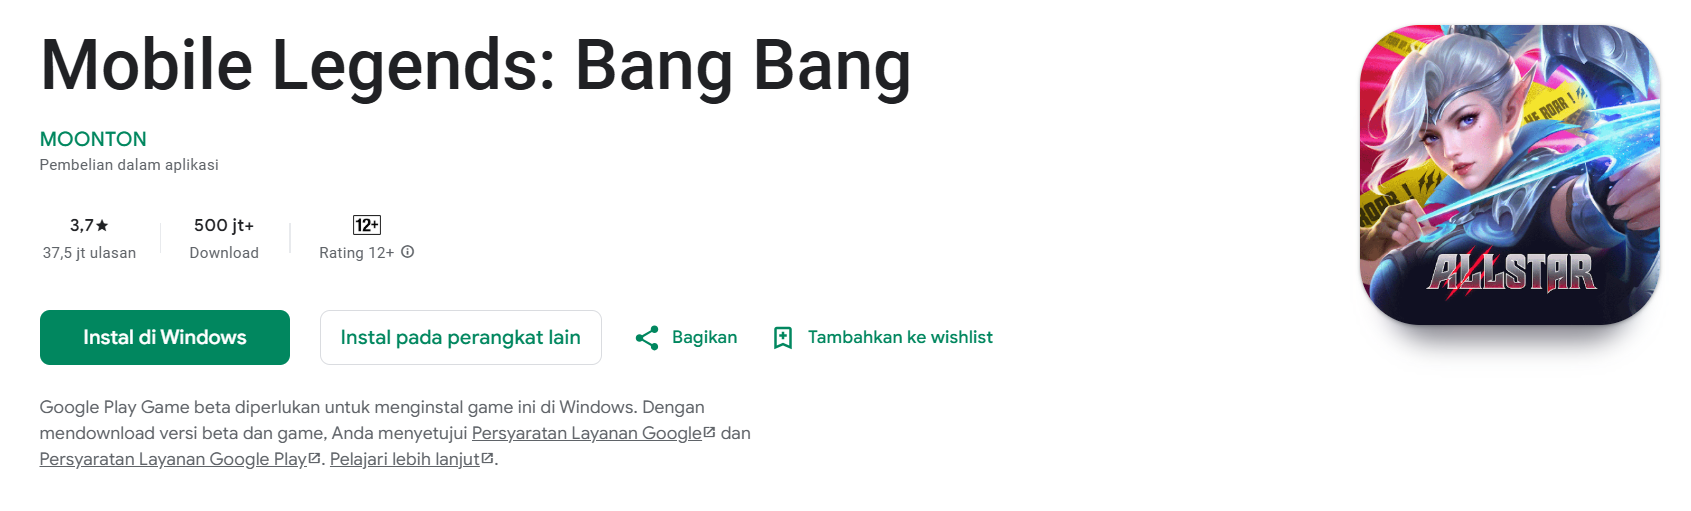

In [27]:
# distribusi lebih detail
df[['content', 'vader_sentiment']].head()

,content,vader_sentiment
0,pengen dapat jarahan raja doang skip aja,netral
1,woi monton ini DM gue Napa tiba' kurang padaha...,netral
2,moonton sangat baik😍,netral
3,"game yang bagus, saya suka dengan game mobile ...",netral
4,game ini main nya 5vs5 atu 1vs9 tolong perbaik...,netral


## **Visualisasi WordCloud**

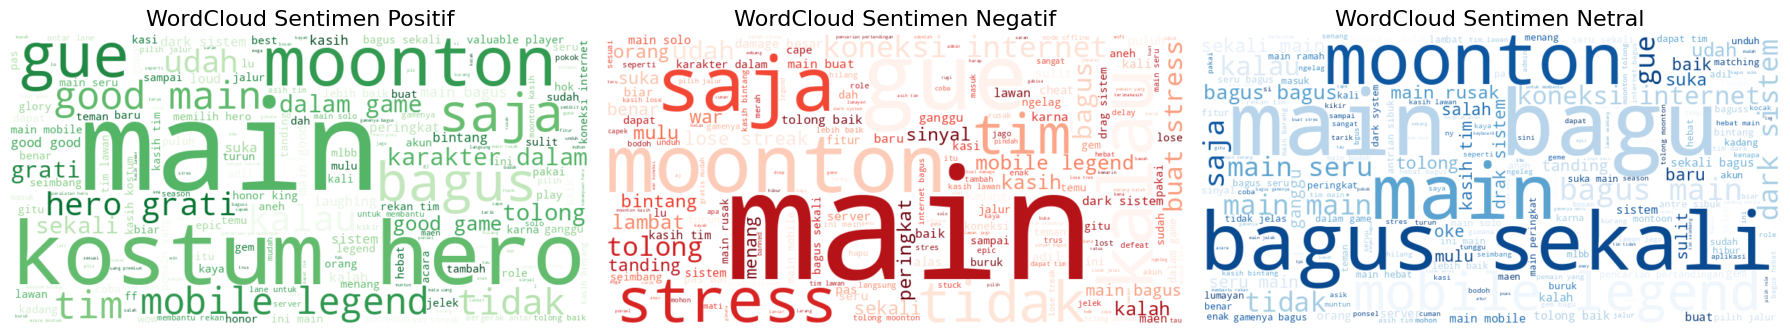

In [29]:
# Gabungkan teks berdasarkan label sentimen
sentiment_texts = {
    sentiment: ' '.join(df[df['vader_sentiment'] == sentiment]['clean_content'])
    for sentiment in ['positif', 'negatif', 'netral']
}

# Membuat wordcloud dengan grid (1x3)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 baris, 3 kolom
colors = {'positif': 'Greens', 'negatif': 'Reds', 'netral': 'Blues'}

for ax, (sentiment, text) in zip(axes, sentiment_texts.items()):
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colors[sentiment],
        max_words=200
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'WordCloud Sentimen {sentiment.capitalize()}', fontsize=16)
    ax.axis('off')

plt.tight_layout()
plt.show()

1. WordCloud Sentimen Positif Kata besar = sering muncul. Contoh:



> main, moonton, bagus, good main, saja, gue



Sebenarnya kata-kata ini masih terdapat bahasa yang kurang baku dan tidak sedikit yang buruk juga. Hal ini dikarenakan ketidaksesuaian antara rating bagus pada aplikasi dengan penyampaian dari player mobile legends tersebut.

2. WordCloud Sentimen Negatif

> main, gue, tidak, stress



Kata-kata yang sering keluar ini hampir mayoritas keluar saat seorang player hampir mengalami yang namanya "kalah". Kata-kata seperti gue, moonton atau stress merupakan kata-kata netral yang sering disampaikan dengan konotasi negatif.

3. WordCloud Sentimen Netral Review yang tidak terlalu memuji atau mengeluh — mungkin sekadar informasi, saran, atau keluhan pribadi.

> bagus sekali, main, moonton

Kata-kata ini sebenarnya adalah kata-kata yang berkonotasi positif, tetapi dikarenakan pengambilan data yang didapat berdasarkan nilai skor dan penilaian yang diberikan tidak sesuai dengan skor rating yang diberikan maka kata-kata tersebut tidak dapat dijadikan sebagai acuan penilaian dari aplikasi mobile legends.

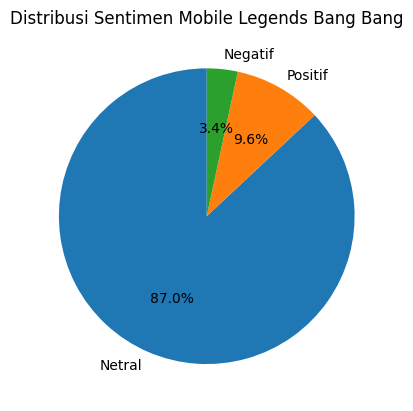

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# 5. Visualisasi Hasil
# Visualisasi distribusi sentimen
sentiment_counts = df['vader_sentiment'].value_counts()
sentiment_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, labels=['Netral', 'Positif', 'Negatif'])
plt.title('Distribusi Sentimen Mobile Legends Bang Bang')
plt.ylabel('')
plt.show()

## **Feature Extraction + Modelling**

### **Skema 1 : SVM, Ekstraksi Fitur: TF-IDF, Pembagian Data: 80/20**

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Ekstraksi fitur TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_content'])

# Label target
y = df['vader_sentiment']

# Pembagian data 80/20
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Model SVM
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Evaluasi
print("SVM + TF-IDF")
print(classification_report(y_test, y_pred_svm))
print("Akurasi:", accuracy_score(y_test, y_pred_svm))

SVM + TF-IDF
              precision    recall  f1-score   support

     negatif       0.99      0.77      0.87       169
      netral       0.98      1.00      0.99      4349
     positif       0.99      0.92      0.95       482

    accuracy                           0.98      5000
   macro avg       0.99      0.90      0.94      5000
weighted avg       0.98      0.98      0.98      5000

Akurasi: 0.984


* Model ini sangat baik secara umum (akurasi hampir 99%)

* Model yang digunakan masih kurang optimal karena mendeteksi review negatif pada sisi recall (negatif: 0.77)

* Data netral masih terlalu dominan (imbalance)

Maka, dari hasil yang kita dapatkan bisa dipertimbangkan untuk melakukan:

1. Gunakan oversampling
2. *Class weight balance di SVM*

### **Skema 2 : Random Forest, Ekstraksi Fitur: Word2Vec, Pembagian Data: 80/20**

In [33]:
from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Training Word2Vec dari token
df['token'] = df['clean_content'].apply(lambda x: x.split())
tokenized = df['token']
w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=2, workers=4)

# Fungsi rata-rata Word2Vec
def vectorize(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# Vektorisasi
X_w2v = np.array([vectorize(tokens, w2v_model) for tokens in tokenized])

# Label target
y = df['vader_sentiment']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
print("Random Forest + Word2Vec")
print(classification_report(y_test, y_pred_rf))
print("Akurasi:", accuracy_score(y_test, y_pred_rf))


Random Forest + Word2Vec
              precision    recall  f1-score   support

     negatif       0.85      0.10      0.18       169
      netral       0.92      1.00      0.96      4349
     positif       0.96      0.57      0.71       482

    accuracy                           0.93      5000
   macro avg       0.91      0.56      0.62      5000
weighted avg       0.93      0.93      0.91      5000

Akurasi: 0.9258


Hasil evaluasi model Random Forest + Word2Vec ini menunjukkan performa yang sangat tidak seimbang antar kelas, meskipun akurasinya terlihat tinggi yaitu 0.928, tapi kenyataannya model hanya selalu menebak "netral" karena itu yang paling banyak.

Ini menyebabkan akurasi menipu karena tidak mencerminkan kualitas deteksi kelas negatif dan positif.

### **Skema 3 : Random Forest, Ekstraksi Fitur: TF-IDF, Pembagian Data: 70/30**

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Ekstraksi fitur TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_content'])

# Label target
y = df['vader_sentiment']

# Pembagian data 70/30
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.3, random_state=42, stratify=y)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
print("Random Forest + TF-IDF")
print(classification_report(y_test, y_pred_rf))
print("Akurasi:", accuracy_score(y_test, y_pred_rf))

Random Forest + TF-IDF
              precision    recall  f1-score   support

     negatif       0.98      0.80      0.88       253
      netral       0.99      1.00      0.99      6523
     positif       0.98      0.91      0.94       724

    accuracy                           0.98      7500
   macro avg       0.98      0.90      0.94      7500
weighted avg       0.98      0.98      0.98      7500

Akurasi: 0.9841333333333333


Hasil evaluasi mode Random Forest + TF-IDF menunjukan akurasi yang hampir sama seperti pada skema 1 yaitu 0.984. Walau begitu masih terjadi ketidakseimbangan pada performa yang dapat dilihat dari nilai "netral" yang paling banyak sehingga menyebabkan akurasi yang tidak dapat ditentukan pastinya untuk mencerminkan kelas negatif dan positif.

## **Conclusion**


Berdasarkan 3 Skema diatas mendapat perolehan score accuracy yaitu :

SVM + TF-IDF + 80/20: Akurasi: 0.984
RF + Word2Vec + 80/30: Akurasi : 0.9272
RF + TF-IDF + 70/20 : Validasi Akurasi mencapai 0.9841333333333333
Maka mari kita simpan untuk performa model terbaik yaitu RF + TF-IDF (Skema 3)

## **Create requirements file**

In [35]:
!pip freeze > requirements.txt

## **Save Models**

Model RF + TF-IDF, dan ini cocok disimpan menggunakan 'pickle' karena baik TfidfVectorizer maupun RandomForestClassifier berasal dari scikit-learn.

In [36]:
import pickle

# Simpan vectorizer dan model dalam satu file (paket)
with open('rf_tfidf_model.pkl', 'wb') as f:
    pickle.dump((tfidf, rf_model), f)

## **Inference**

In [37]:
# Load vectorizer dan model
with open('rf_tfidf_model.pkl', 'rb') as f:
    tfidf_loaded, rf_model_loaded = pickle.load(f)

# Contoh prediksi ulang
text_baru = [
    "kostum hero bagus",   # positif
    "main mobile legends semakin stress",  # negatif
    "saran saya aplikasi diperbarui",  # netral
]

X_new = tfidf_loaded.transform(text_baru)
prediksi = rf_model_loaded.predict(X_new)

print("Prediksi:", prediksi)

Prediksi: ['positif' 'negatif' 'netral']
